In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import FastText
from gensim.utils import simple_preprocess

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Train a FastText model
print("Training FastText model...")
sentences = data[text_column].apply(simple_preprocess).tolist()
fasttext_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Step 2: Create a FastText embedding matrix
embedding_dim = 100
word_index = {word: i + 1 for i, word in enumerate(fasttext_model.wv.index_to_key)}
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    embedding_vector = fasttext_model.wv[word]
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Step 3: Convert text data into sequences of FastText indices
def text_to_sequence(text):
    return [word_index.get(word, 0) for word in simple_preprocess(text)]

data['fasttext_seq'] = data[text_column].apply(text_to_sequence)

# Pad the sequences
max_len = 100
X = pad_sequences(data['fasttext_seq'], maxlen=max_len, padding='post', truncating='post')
y = data[target_column]

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Build the GRU model with FastText embeddings
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              input_length=max_len, 
              trainable=False),  # Keep FastText embeddings fixed
    GRU(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the GRU model
print("Training GRU Model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Step 7: Evaluate the GRU model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"GRU Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Save the trained GRU model
model_path = r"C:\Users\PC\Downloads\GRU_model_fasttext.h5"
model.save(model_path)
print(f"Trained GRU model saved to {model_path}")

# Step 9: Classification Report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

Training FastText model...


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training GRU Model...
Epoch 1/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 225s 48ms/step - accuracy: 0.8653 - loss: 0.2938 - val_accuracy: 0.9435 - val_loss: 0.1518
Epoch 2/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 215s 46ms/step - accuracy: 0.9482 - loss: 0.1385 - val_accuracy: 0.9508 - val_loss: 0.1322
Epoch 3/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 217s 47ms/step - accuracy: 0.9550 - loss: 0.1206 - val_accuracy: 0.9523 - val_loss: 0.1281
Epoch 4/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 216s 46ms/step - accuracy: 0.9603 - loss: 0.1075 - val_accuracy: 0.9501 - val_loss: 0.1321
Epoch 5/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 219s 47ms/step - accuracy: 0.9630 - loss: 0.0989 - val_accuracy: 0.9518 - val_loss: 0.1278
Epoch 6/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 236s 51ms/step - accuracy: 0.9664 - loss: 0.0919 - val_accuracy: 0.9555 - val_loss: 0.1195
Epoch 7/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 223s 48ms/step - accuracy: 0.9688 - loss: 0.0854 - val_accuracy: 0.9559 - val_loss: 0.1227
Epoch 8/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 213s 

GRU Test Accuracy: 95.45%
Trained GRU model saved to C:\Users\PC\Downloads\GRU_model_fasttext.h5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     23238
           1       0.96      0.95      0.95     23171

    accuracy                           0.95     46409
   macro avg       0.95      0.95      0.95     46409
weighted avg       0.95      0.95      0.95     46409

Accuracy: 95.45%
Precision: 96.09%
Recall: 94.75%
F1 Score: 95.41%


Training FastText model...


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training GRU Model...
Epoch 1/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 245s 52ms/step - accuracy: 0.8764 - loss: 0.2902 - val_accuracy: 0.9417 - val_loss: 0.1570
Epoch 2/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 239s 51ms/step - accuracy: 0.9422 - loss: 0.1536 - val_accuracy: 0.9378 - val_loss: 0.1627
Epoch 3/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 231s 50ms/step - accuracy: 0.9524 - loss: 0.1260 - val_accuracy: 0.9524 - val_loss: 0.1280
Epoch 4/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 231s 50ms/step - accuracy: 0.9585 - loss: 0.1118 - val_accuracy: 0.9541 - val_loss: 0.1241
Epoch 5/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 227s 49ms/step - accuracy: 0.9616 - loss: 0.1012 - val_accuracy: 0.9550 - val_loss: 0.1205
Epoch 6/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 224s 48ms/step - accuracy: 0.9654 - loss: 0.0940 - val_accuracy: 0.9560 - val_loss: 0.1197
Epoch 7/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 225s 49ms/step - accuracy: 0.9675 - loss: 0.0867 - val_accuracy: 0.9529 - val_loss: 0.1292
Epoch 8/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 225s 

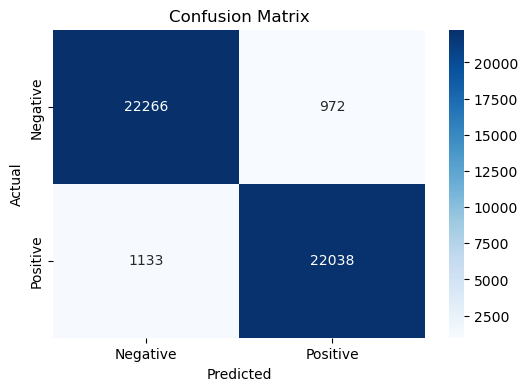

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import FastText
from gensim.utils import simple_preprocess

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Train a FastText model
print("Training FastText model...")
sentences = data[text_column].apply(simple_preprocess).tolist()
fasttext_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Step 2: Create a FastText embedding matrix
embedding_dim = 100
word_index = {word: i + 1 for i, word in enumerate(fasttext_model.wv.index_to_key)}
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    embedding_vector = fasttext_model.wv[word]
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Step 3: Convert text data into sequences of FastText indices
def text_to_sequence(text):
    return [word_index.get(word, 0) for word in simple_preprocess(text)]

data['fasttext_seq'] = data[text_column].apply(text_to_sequence)

# Pad the sequences
max_len = 100
X = pad_sequences(data['fasttext_seq'], maxlen=max_len, padding='post', truncating='post')
y = data[target_column]

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Build the GRU model with FastText embeddings
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              input_length=max_len, 
              trainable=False),  # Keep FastText embeddings fixed
    GRU(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the GRU model
print("Training GRU Model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Step 7: Evaluate the GRU model
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Step 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Training FastText model...


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training GRU Model...
Epoch 1/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 242s 51ms/step - accuracy: 0.8751 - loss: 0.2919 - val_accuracy: 0.9396 - val_loss: 0.1630
Epoch 2/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 233s 50ms/step - accuracy: 0.9439 - loss: 0.1502 - val_accuracy: 0.9488 - val_loss: 0.1364
Epoch 3/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 230s 49ms/step - accuracy: 0.9543 - loss: 0.1236 - val_accuracy: 0.9518 - val_loss: 0.1278
Epoch 4/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 224s 48ms/step - accuracy: 0.9585 - loss: 0.1122 - val_accuracy: 0.9517 - val_loss: 0.1275
Epoch 5/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 222s 48ms/step - accuracy: 0.9625 - loss: 0.1016 - val_accuracy: 0.9555 - val_loss: 0.1189
Epoch 6/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 225s 48ms/step - accuracy: 0.9657 - loss: 0.0934 - val_accuracy: 0.9528 - val_loss: 0.1263
Epoch 7/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 220s 47ms/step - accuracy: 0.9678 - loss: 0.0867 - val_accuracy: 0.9545 - val_loss: 0.1247
Epoch 8/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 219s 

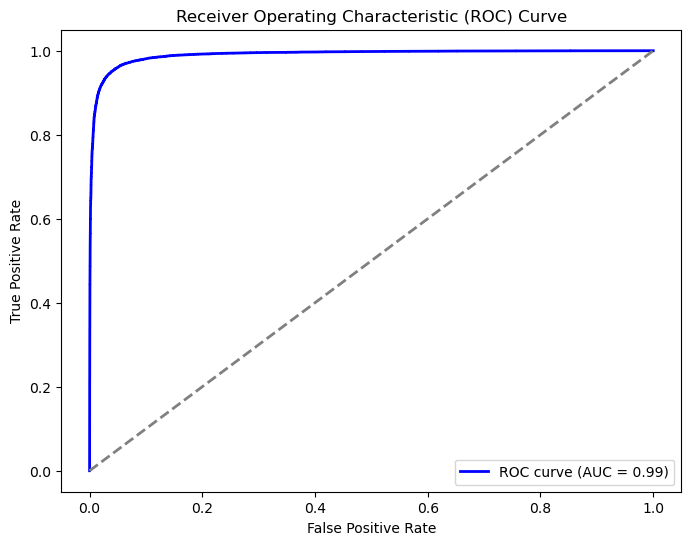

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import FastText
from gensim.utils import simple_preprocess

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Train a FastText model
print("Training FastText model...")
sentences = data[text_column].apply(simple_preprocess).tolist()
fasttext_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Step 2: Create a FastText embedding matrix
embedding_dim = 100
word_index = {word: i + 1 for i, word in enumerate(fasttext_model.wv.index_to_key)}
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    embedding_vector = fasttext_model.wv[word]
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Step 3: Convert text data into sequences of FastText indices
def text_to_sequence(text):
    return [word_index.get(word, 0) for word in simple_preprocess(text)]

data['fasttext_seq'] = data[text_column].apply(text_to_sequence)

# Pad the sequences
max_len = 100
X = pad_sequences(data['fasttext_seq'], maxlen=max_len, padding='post', truncating='post')
y = data[target_column]

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Build the GRU model with FastText embeddings
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              input_length=max_len, 
              trainable=False),  # Keep FastText embeddings fixed
    GRU(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the GRU model
print("Training GRU Model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Step 7: ROC Curve
y_pred_proba = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


Training FastText model...


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training GRU Model...
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 256s 54ms/step - accuracy: 0.8723 - loss: 0.2951 - val_accuracy: 0.9384 - val_loss: 0.1642
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step


C:\Users\PC\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


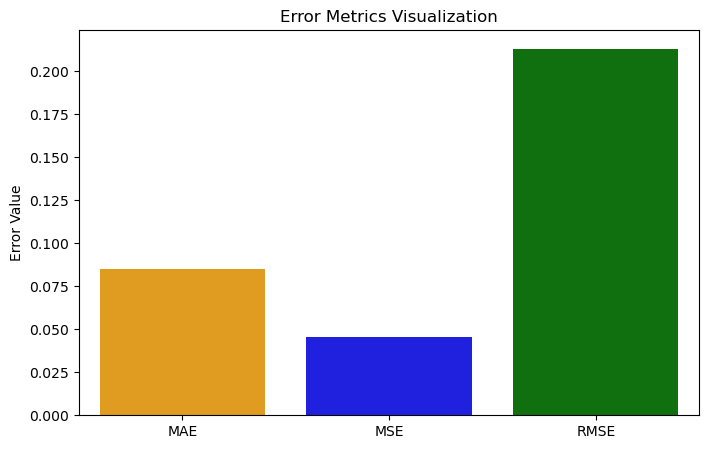

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import FastText
from gensim.utils import simple_preprocess

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Train a FastText model
print("Training FastText model...")
sentences = data[text_column].apply(simple_preprocess).tolist()
fasttext_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Step 2: Create a FastText embedding matrix
embedding_dim = 100
word_index = {word: i + 1 for i, word in enumerate(fasttext_model.wv.index_to_key)}
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    embedding_vector = fasttext_model.wv[word]
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Step 3: Convert text data into sequences of FastText indices
def text_to_sequence(text):
    return [word_index.get(word, 0) for word in simple_preprocess(text)]

data['fasttext_seq'] = data[text_column].apply(text_to_sequence)

# Pad the sequences
max_len = 100
X = pad_sequences(data['fasttext_seq'], maxlen=max_len, padding='post', truncating='post')
y = data[target_column]

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Build the GRU model with FastText embeddings
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              input_length=max_len, 
              trainable=False),  # Keep FastText embeddings fixed
    GRU(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the GRU model
print("Training GRU Model...")
model.fit(X_train, y_train, batch_size=32, validation_split=0.2)

# Step 7: Evaluate the GRU model
y_pred_prob = model.predict(X_test).flatten()

# Step 8: Calculate MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred_prob)
mse = mean_squared_error(y_test, y_pred_prob)
rmse = np.sqrt(mse)

# Step 9: Visualization
metrics = ['MAE', 'MSE', 'RMSE']
values = [mae, mse, rmse]
colors = ['orange', 'blue', 'green']

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, palette=colors)
plt.title('Error Metrics Visualization')
plt.ylabel('Error Value')
plt.show()


Training FastText model...


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training GRU Model...
Epoch 1/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 275s 58ms/step - accuracy: 0.8712 - loss: 0.3036 - val_accuracy: 0.9334 - val_loss: 0.1801
Epoch 2/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 272s 59ms/step - accuracy: 0.9389 - loss: 0.1603 - val_accuracy: 0.9468 - val_loss: 0.1434
Epoch 3/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 270s 58ms/step - accuracy: 0.9520 - loss: 0.1289 - val_accuracy: 0.9525 - val_loss: 0.1305
Epoch 4/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 259s 56ms/step - accuracy: 0.9587 - loss: 0.1118 - val_accuracy: 0.9529 - val_loss: 0.1242
Epoch 5/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 261s 56ms/step - accuracy: 0.9622 - loss: 0.1010 - val_accuracy: 0.9532 - val_loss: 0.1258
Epoch 6/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 256s 55ms/step - accuracy: 0.9651 - loss: 0.0937 - val_accuracy: 0.9554 - val_loss: 0.1190
Epoch 7/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 254s 55ms/step - accuracy: 0.9679 - loss: 0.0877 - val_accuracy: 0.9559 - val_loss: 0.1197
Epoch 8/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 251s 

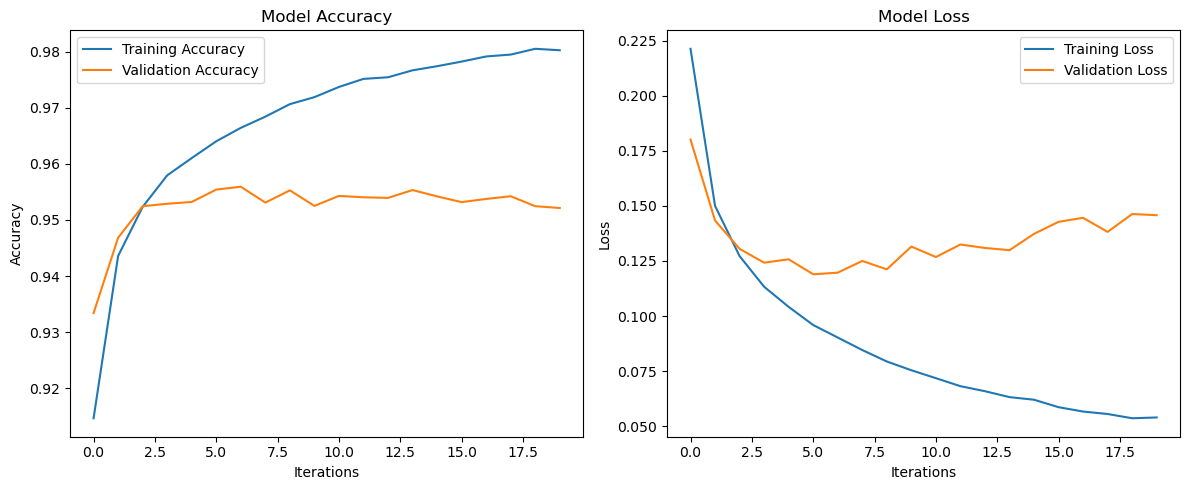

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import FastText
from gensim.utils import simple_preprocess

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Train a FastText model
print("Training FastText model...")
sentences = data[text_column].apply(simple_preprocess).tolist()
fasttext_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Step 2: Create a FastText embedding matrix
embedding_dim = 100
word_index = {word: i + 1 for i, word in enumerate(fasttext_model.wv.index_to_key)}
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, i in word_index.items():
    embedding_vector = fasttext_model.wv[word]
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Step 3: Convert text data into sequences of FastText indices
def text_to_sequence(text):
    return [word_index.get(word, 0) for word in simple_preprocess(text)]

data['fasttext_seq'] = data[text_column].apply(text_to_sequence)

# Pad the sequences
max_len = 100
X = pad_sequences(data['fasttext_seq'], maxlen=max_len, padding='post', truncating='post')
y = data[target_column]

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Build the GRU model with FastText embeddings
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              input_length=max_len, 
              trainable=False),  # Keep FastText embeddings fixed
    GRU(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the GRU model
print("Training GRU Model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Step 7: Evaluate the GRU model
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Step 8: Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()